[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Segment Anything Model (SAM)

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/segment-anything) [![arXiv](https://img.shields.io/badge/arXiv-2304.02643-b31b1b.svg)](https://arxiv.org/abs/2304.02643)

Segment Anything Model (SAM): a new AI model from Meta AI that can "cut out" any object, in any image, with a single click. SAM is a promptable segmentation system with zero-shot generalization to unfamiliar objects and images, without the need for additional training. This notebook is an extension of the [official notebook](https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb) prepared by Meta AI.

![segment anything model](https://media.roboflow.com/notebooks/examples/segment-anything-model-paper.png)

## Complementary Materials

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/D-D6ZmadzPE) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-use-segment-anything-model-sam)

We recommend that you follow along in this notebook while reading the blog post on Segment Anything Model.

![segment anything model blogpost](https://media.roboflow.com/notebooks/examples/segment-anything-model-blogpost.png)

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- **Before you start** - Make sure you have access to the GPU
- Install Segment Anything Model (SAM)
- Download Example Data
- Load Model
- Automated Mask Generation
- Generate Segmentation with Bounding Box
- Segment Anything in Roboflow Universe Dataset

## Let's begin!

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Wed Mar 18 14:30:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install Segment Anything Model (SAM) and other dependencies

In [3]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [4]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.1 MB/s eta 0:00:00


### Download SAM weights

In [5]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [6]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/content/weights/sam_vit_h_4b8939.pth ; exist: True


## Download Example Data

**NONE:** Let's download few example images. Feel free to use your images or videos.

In [7]:
!mkdir -p {HOME}/data

!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data

## Load Model

In [8]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [9]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [10]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [11]:
import os

IMAGE_NAME = "badminton.jpeg"
IMAGE_PATH = "/content/Screenshot 2026-03-18 200141.png"

### Generate masks with SAM

In [12]:
import cv2
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam_result = mask_generator.generate(image_rgb)

### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

In [13]:
print(sam_result[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

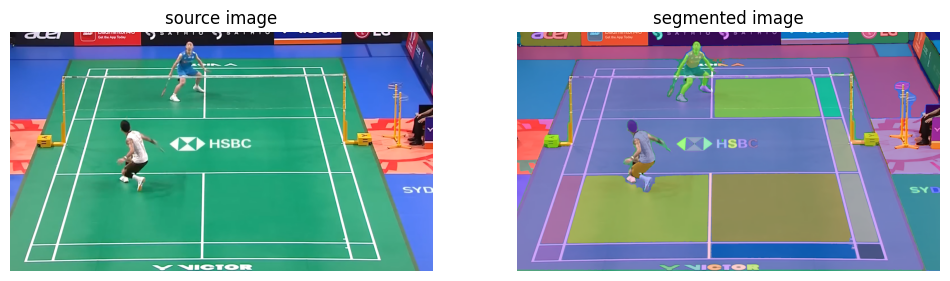

In [14]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

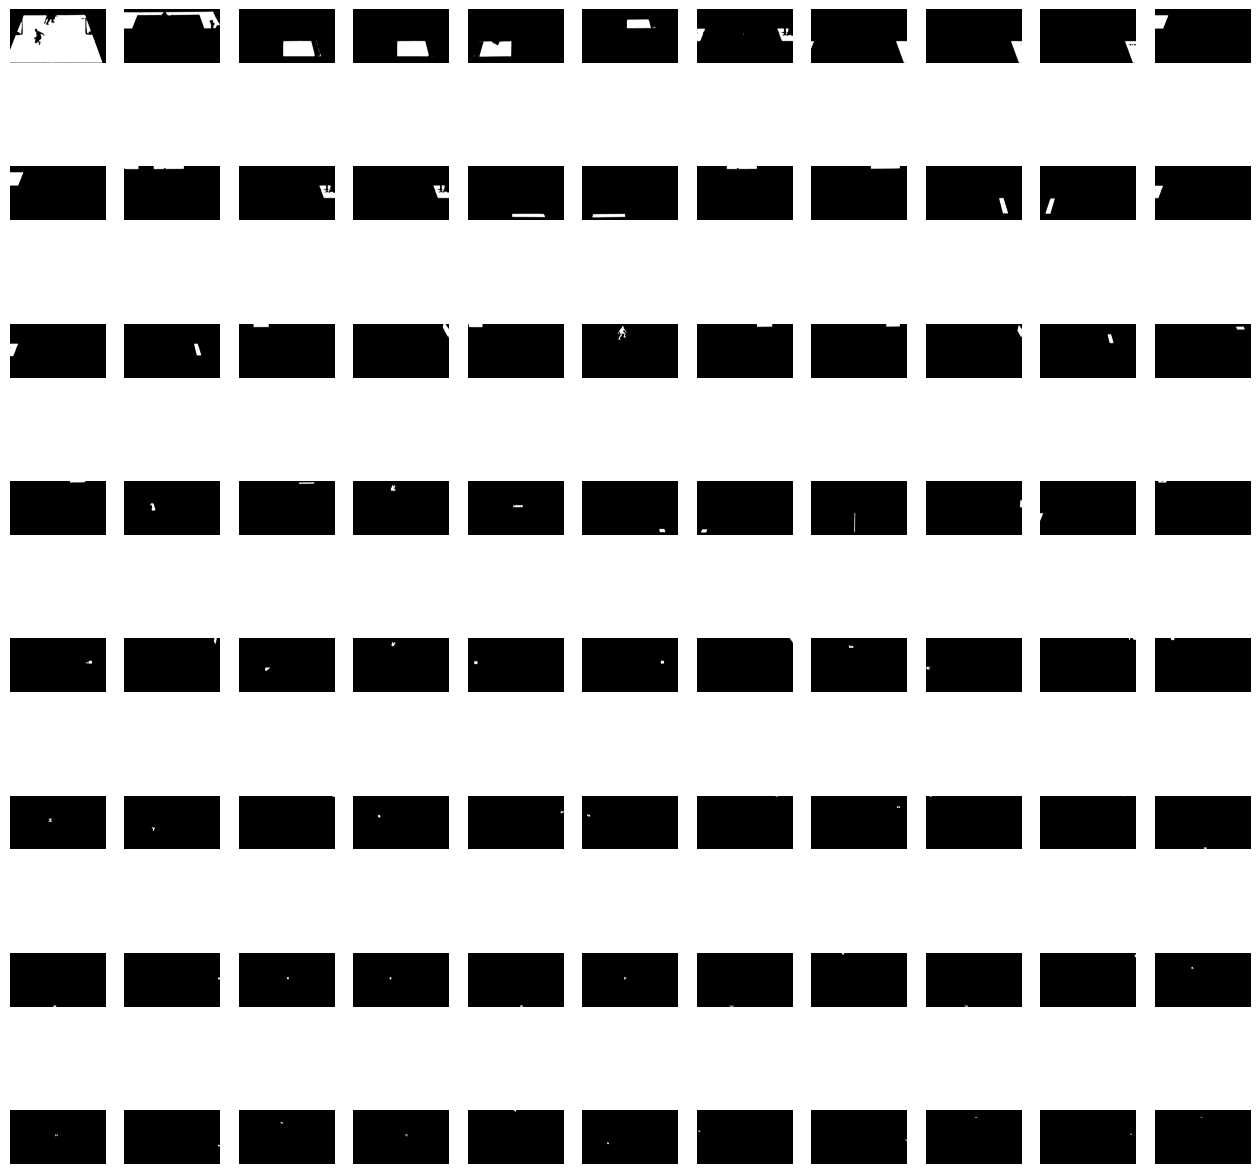

In [15]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks) / 8)),
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [16]:
mask_predictor = SamPredictor(sam)

In [18]:
import os

IMAGE_NAME = "badminton.jpeg"
IMAGE_PATH = "/content/Screenshot 2026-03-18 200141.png"

### Draw Box



In [53]:
# helper function that loads an image before adding it to the widget

import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

**NOTE:** Execute cell below and use your mouse to draw bounding box on the image 👇

In [54]:
IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

widget = BBoxWidget()
widget.image = encode_image(IMAGE_PATH)
widget

In [55]:
widget.bboxes

[{'x': 172, 'y': 135, 'width': 1024, 'height': 263, 'label': ''}]

### Generate masks with SAM

**NOTE:** `SamPredictor.predict` method takes `np.ndarray` `box` argument in `[x_min, y_min, x_max, y_max]` format. Let's reorganise your data first

In [67]:
import numpy as np

# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 68, 'y': 247, 'width': 555, 'height': 678, 'label': ''}

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'],
    box['y'],
    box['x'] + box['width'],
    box['y'] + box['height']
])

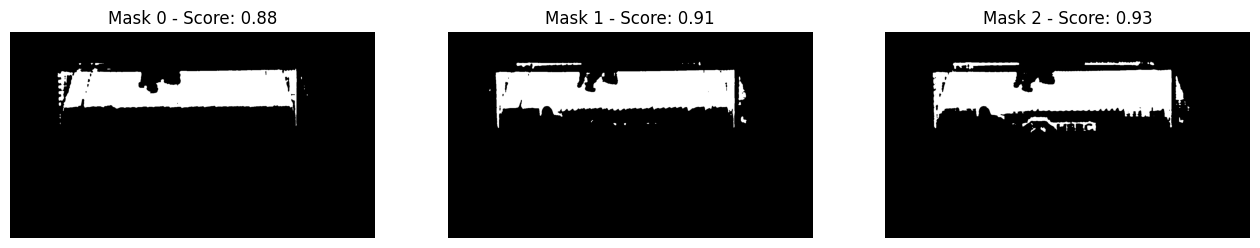

In [68]:
import supervision as sv

# This helps you see if the mesh appeared in one of the other 3 masks
sv.plot_images_grid(
    images=masks,
    grid_size=(1, 3),
    size=(16, 4),
    titles=[f"Mask {i} - Score: {scores[i]:.2f}" for i in range(len(scores))]
)

In [69]:
import cv2
import numpy as np
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
)

### Results visualisation with Supervision

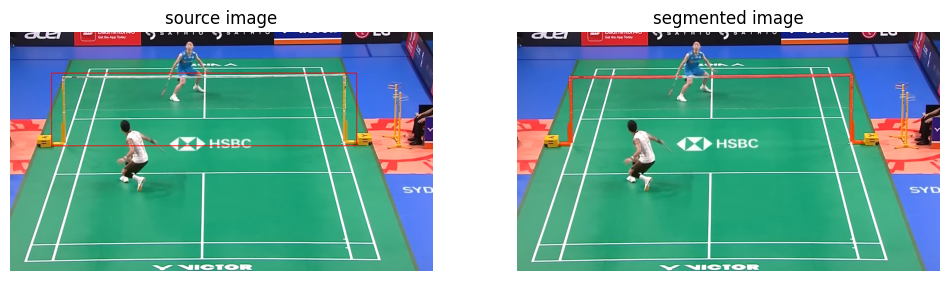

In [70]:
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

source_image = box_annotator.annotate(scene=image_bgr.copy(), detections=detections)
segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[source_image, segmented_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

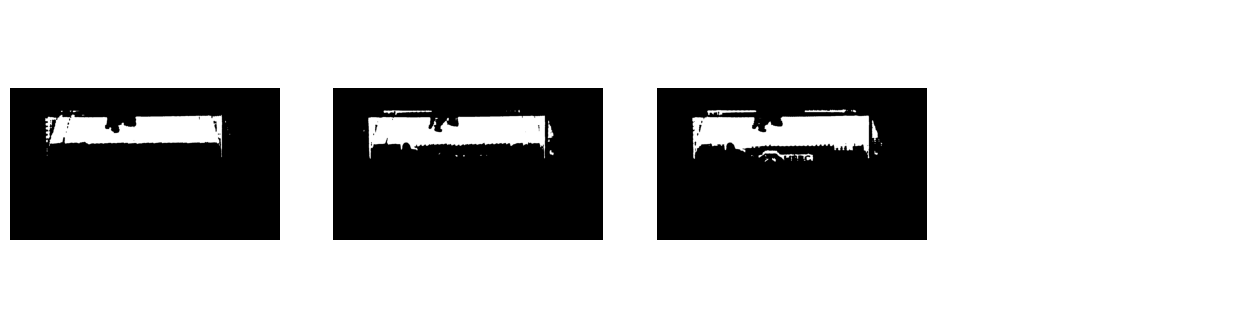

In [64]:
import supervision as v

sv.plot_images_grid(
    images=masks,
    grid_size=(1, 4),
    size=(16, 4)
)

## Segment Anything in Roboflow Universe Dataset

### Utils Supporting Dataset Processing

A couple of helper functions that, unfortunately, we have to write ourselves to facilitate the processing of COCO annotations.

In [26]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections


@dataclass_json
@dataclass
class COCOCategory:
    id: int
    name: str
    supercategory: str


@dataclass_json
@dataclass
class COCOImage:
    id: int
    width: int
    height: int
    file_name: str
    license: int
    date_captured: str
    coco_url: Optional[str] = None
    flickr_url: Optional[str] = None


@dataclass_json
@dataclass
class COCOAnnotation:
    id: int
    image_id: int
    category_id: int
    segmentation: List[List[float]]
    area: float
    bbox: Tuple[float, float, float, float]
    iscrowd: int


@dataclass_json
@dataclass
class COCOLicense:
    id: int
    name: str
    url: str


@dataclass_json
@dataclass
class COCOJson:
    images: List[COCOImage]
    annotations: List[COCOAnnotation]
    categories: List[COCOCategory]
    licenses: List[COCOLicense]


def load_coco_json(json_file: str) -> COCOJson:
    import json

    with open(json_file, "r") as f:
        json_data = json.load(f)

    return COCOJson.from_dict(json_data)


class COCOJsonUtility:
    @staticmethod
    def get_annotations_by_image_id(coco_data: COCOJson, image_id: int) -> List[COCOAnnotation]:
        return [annotation for annotation in coco_data.annotations if annotation.image_id == image_id]

    @staticmethod
    def get_annotations_by_image_path(coco_data: COCOJson, image_path: str) -> Optional[List[COCOAnnotation]]:
        image = COCOJsonUtility.get_image_by_path(coco_data, image_path)
        if image:
            return COCOJsonUtility.get_annotations_by_image_id(coco_data, image.id)
        else:
            return None

    @staticmethod
    def get_image_by_path(coco_data: COCOJson, image_path: str) -> Optional[COCOImage]:
        for image in coco_data.images:
            if image.file_name == image_path:
                return image
        return None

    @staticmethod
    def annotations2detections(annotations: List[COCOAnnotation]) -> Detections:
        class_id, xyxy = [], []

        for annotation in annotations:
            x_min, y_min, width, height = annotation.bbox
            class_id.append(annotation.category_id)
            xyxy.append([
                x_min,
                y_min,
                x_min + width,
                y_min + height
            ])

        return Detections(
            xyxy=np.array(xyxy, dtype=int),
            class_id=np.array(class_id, dtype=int)
        )

### Download Dataset from Roboflow

In [28]:
# Install the roboflow library
!pip install roboflow

import os
from roboflow import Roboflow

# Initialize Roboflow with your specific API key
rf = Roboflow(api_key="ojaOdZy3uM9l0ri6psvN")

# Access the Badminton Court Keypoint project
project = rf.workspace("ritesh-3iojl").project("badminton-court-keypoint-dataset-eecdf")

# Download version 4 of the dataset in COCO format
version = project.version(4)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Badminton-Court-Keypoint-Dataset-4 in coco:: 100%|██████████| 6447/6447 [00:01<00:00, 3601.00it/s]


In [29]:
import os

DATA_SET_SUBDIRECTORY = "test"
ANNOTATIONS_FILE_NAME = "_annotations.coco.json"
IMAGES_DIRECTORY_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY)
ANNOTATIONS_FILE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, ANNOTATIONS_FILE_NAME)

In [30]:
coco_data = load_coco_json(json_file=ANNOTATIONS_FILE_PATH)

CLASSES = [
    category.name
    for category
    in coco_data.categories
    if category.supercategory != 'none'
]

IMAGES = [
    image.file_name
    for image
    in coco_data.images
]

In [33]:
CLASSES

['Net_Line', 'courtline']

### Single Image Bounding Box to Mask

In [34]:
# set random seed to allow easy reproduction of the experiment

import random
random.seed(10)

In [36]:
EXAMPLE_IMAGE_NAME = random.choice(IMAGES)
EXAMPLE_IMAGE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, EXAMPLE_IMAGE_NAME)

# load dataset annotations
annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)
ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

# small hack - coco numerate classes from 1, model from 0 + we drop first redundant class from coco json
ground_truth.class_id = ground_truth.class_id - 1

# load image
image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# initiate annotator
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

# annotate ground truth
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

# run SAM inference
mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=ground_truth.xyxy[0],
    multimask_output=True
)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[annotated_frame_ground_truth, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

TypeError: 'COCOJson' object is not subscriptable

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.

ERROR: Could not find a version that satisfies the requirement segment-anything-2 (from versions: none)
ERROR: No matching distribution found for segment-anything-2
loading Roboflow workspace...
loading Roboflow project...


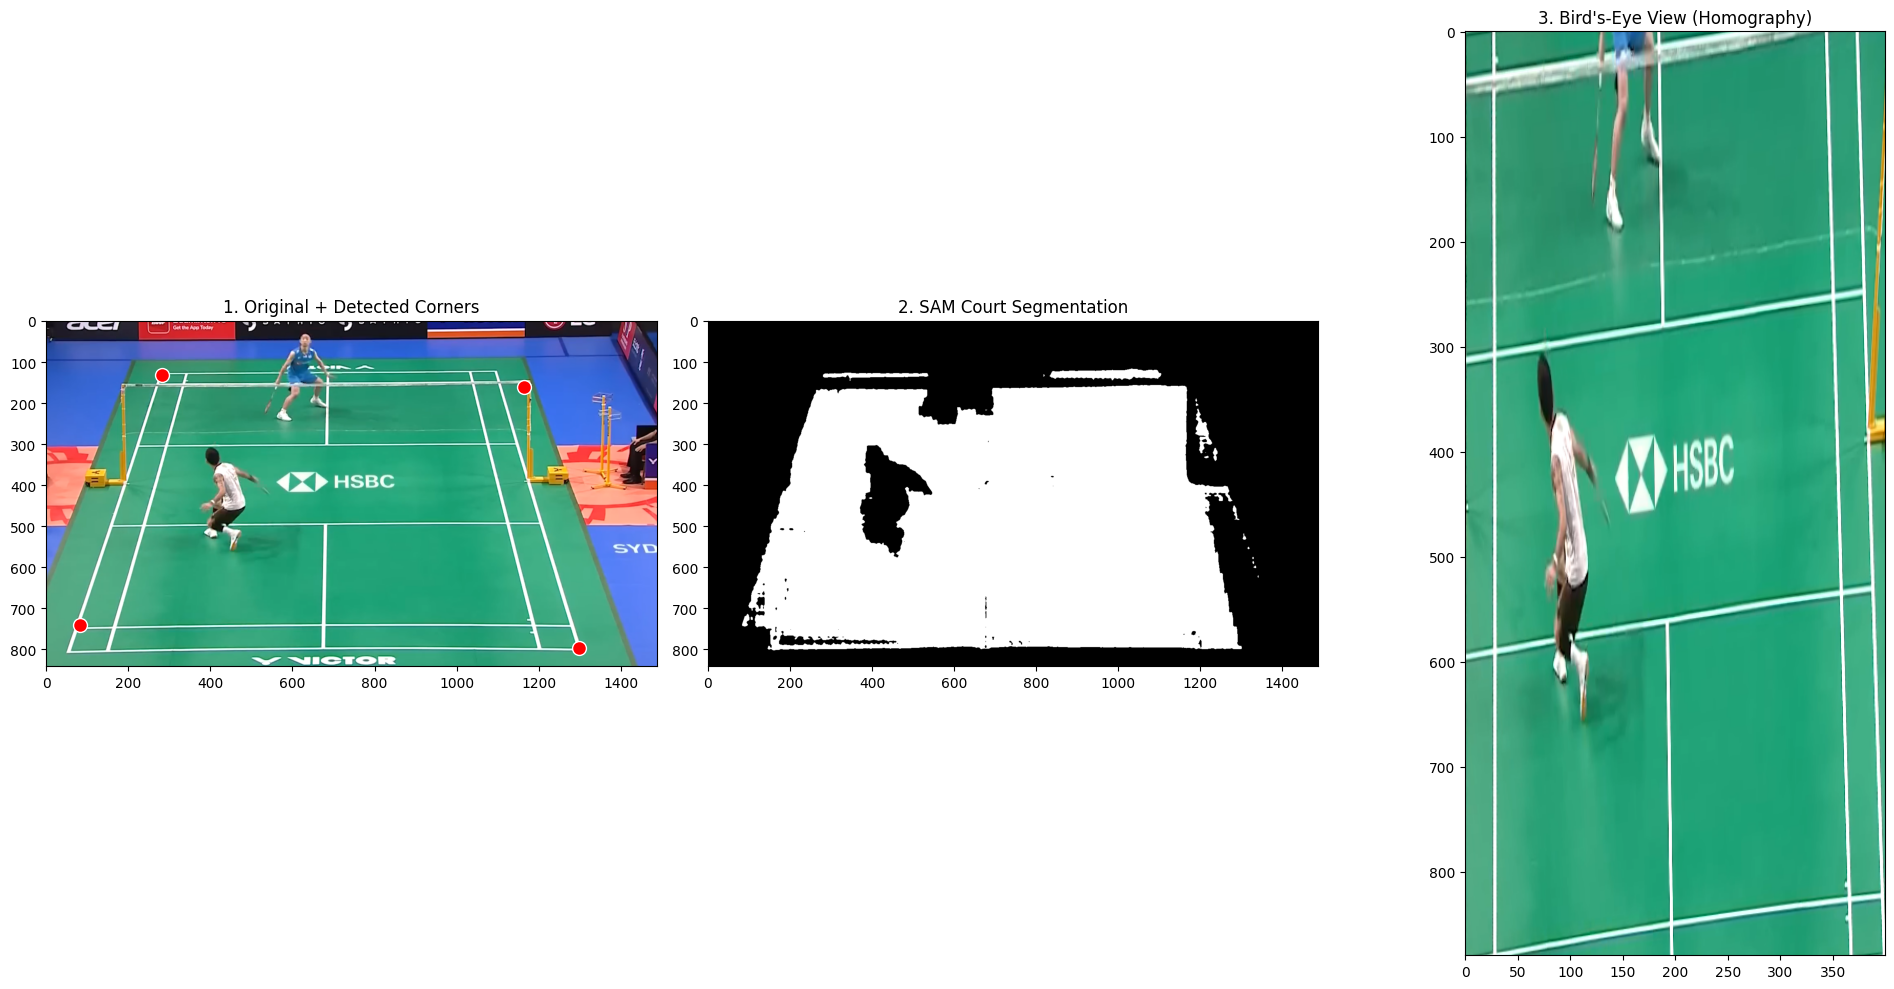

In [73]:
# --- STEP 1: Setup and Data Download ---
!pip install -q roboflow supervision segment-anything-2

import os
import cv2
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt
from roboflow import Roboflow

# Initialize Roboflow and download your specific dataset
rf = Roboflow(api_key="ojaOdZy3uM9l0ri6psvN")
project = rf.workspace("ritesh-3iojl").project("badminton-court-keypoint-dataset-eecdf")
dataset = project.version(4).download("coco")

# --- STEP 2: Load Image and Model ---
# Picking a random image from the downloaded dataset
IMAGE_DIR = os.path.join(dataset.location, "train")
IMAGE_NAME = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.png'))][0]
IMAGE_PATH = "/content/Screenshot 2026-03-18 200141.png"

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# --- STEP 3: Segmentation with SAM ---
# Note: Ensure mask_predictor (SAM) is already initialized in your environment
mask_predictor.set_image(image_rgb)

# We define a broad box for the court area (or use your widget logic)
# For this full code, let's assume a standard centered box if no widget exists
h, w, _ = image_bgr.shape
court_box = np.array([w*0.1, h*0.2, w*0.9, h*0.9]) # [x_min, y_min, x_max, y_max]

masks, scores, logits = mask_predictor.predict(
    box=court_box,
    multimask_output=True
)

# Select the most likely mask for the court
best_mask_idx = np.argmax(scores)
court_mask = masks[best_mask_idx]

# --- STEP 4: Corner Detection from Mask ---
# Find all pixels that belong to the court
points = np.argwhere(court_mask)
points = points[:, [1, 0]] # Switch to [x, y]

# Identify the 4 extreme corners of the detected court area
s = points.sum(axis=1)
diff = np.diff(points, axis=1)

top_left     = points[np.argmin(s)]
bottom_right = points[np.argmax(s)]
top_right    = points[np.argmin(diff)]
bottom_left  = points[np.argmax(diff)]

src_pts = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")

# --- STEP 5: Apply Homography (Perspective Warp) ---
# Destination: A standard 2D rectangle (Badminton ratio is ~1:2.2)
dst_w, dst_h = 400, 880
dst_pts = np.array([
    [0, 0],
    [dst_w - 1, 0],
    [dst_w - 1, dst_h - 1],
    [0, dst_h - 1]
], dtype="float32")

# Calculate the transformation matrix
H, _ = cv2.findHomography(src_pts, dst_pts)
birdseye_view = cv2.warpPerspective(image_rgb, H, (dst_w, dst_h))

# --- STEP 6: Final Visualization ---
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

# Plot 1: Source with detected corners
ax[0].imshow(image_rgb)
ax[0].scatter(src_pts[:, 0], src_pts[:, 1], color='red', s=100, edgecolors='white')
ax[0].set_title("1. Original + Detected Corners")

# Plot 2: The Mask
ax[1].imshow(court_mask, cmap='gray')
ax[1].set_title("2. SAM Court Segmentation")

# Plot 3: The Bird's-Eye View
ax[2].imshow(birdseye_view)
ax[2].set_title("3. Bird's-Eye View (Homography)")

plt.tight_layout()
plt.show()

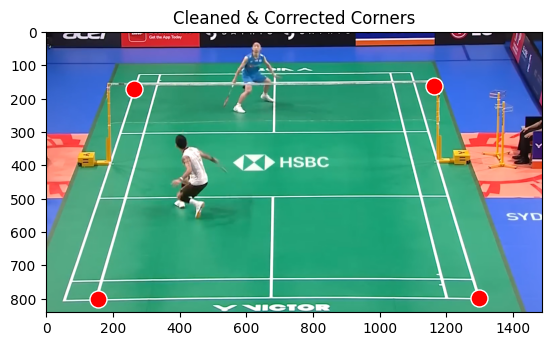

In [74]:
import cv2
import numpy as np

# --- 1. Clean the SAM Mask ---
# Convert boolean mask to uint8 (0 and 255)
mask_uint8 = court_mask.astype(np.uint8) * 255

# Apply 'Morphological Opening' to remove small noisy dots/islands
kernel = np.ones((7, 7), np.uint8)
cleaned_mask = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)

# --- 2. Keep ONLY the Largest Object (The Court) ---
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    largest_contour = max(contours, key=cv2.contourArea)

    # Create a new blank mask with only the largest contour
    final_court_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(final_court_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
else:
    final_court_mask = cleaned_mask # Fallback

# --- 3. Extract 4 Corners from the Cleaned Mask ---
points = np.argwhere(final_court_mask > 0)
points = points[:, [1, 0]] # Switch to [x, y]

s = points.sum(axis=1)
diff = np.diff(points, axis=1)

tl = points[np.argmin(s)]
br = points[np.argmax(s)]
tr = points[np.argmin(diff)]
bl = points[np.argmax(diff)]

src_pts = np.array([tl, tr, br, bl], dtype="float32")

# --- 4. Final Visualization (Update your plot) ---
plt.imshow(image_rgb)
plt.scatter(src_pts[:, 0], src_pts[:, 1], color='red', s=150, edgecolors='white')
plt.title("Cleaned & Corrected Corners")
plt.show()

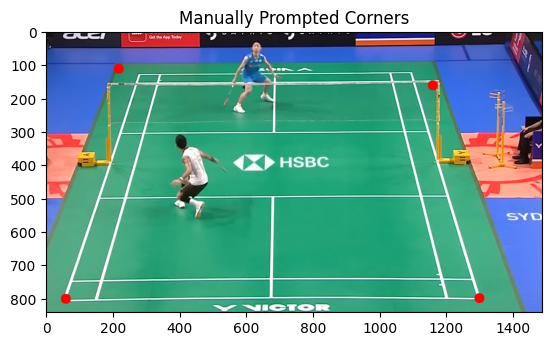

In [75]:
import cv2
import numpy as np
import supervision as sv

# 1. Define your prompts manually for THIS image
# [x_min, y_min, x_max, y_max] - Tighten this to just the green area
court_box = np.array([120, 150, 1300, 800])

# Add a "Positive Point" (Label 1) in the middle of the green
# Add a "Negative Point" (Label 0) on the distracting red banner at the top
input_points = np.array([[700, 500], [700, 50]])
input_labels = np.array([1, 0])

# 2. Predict using the "Hints"
mask_predictor.set_image(image_rgb)
masks, scores, logits = mask_predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    box=court_box,
    multimask_output=True
)

# 3. Select the best version
# SAM gives 3 options; usually the one with the highest score is best
best_mask = masks[np.argmax(scores)]

# 4. Clean up and get corners
points = np.argwhere(best_mask > 0)
points = points[:, [1, 0]]

s = points.sum(axis=1)
diff = np.diff(points, axis=1)

# Extract 4 corners
src_pts = np.array([
    points[np.argmin(s)],    # Top-Left
    points[np.argmin(diff)], # Top-Right
    points[np.argmax(s)],    # Bottom-Right
    points[np.argmax(diff)]  # Bottom-Left
], dtype="float32")

# 5. Visualize to check alignment
annotated_image = image_rgb.copy()
for pt in src_pts:
    cv2.circle(annotated_image, tuple(pt.astype(int)), 15, (255, 0, 0), -1)

plt.imshow(annotated_image)
plt.title("Manually Prompted Corners")
plt.show()


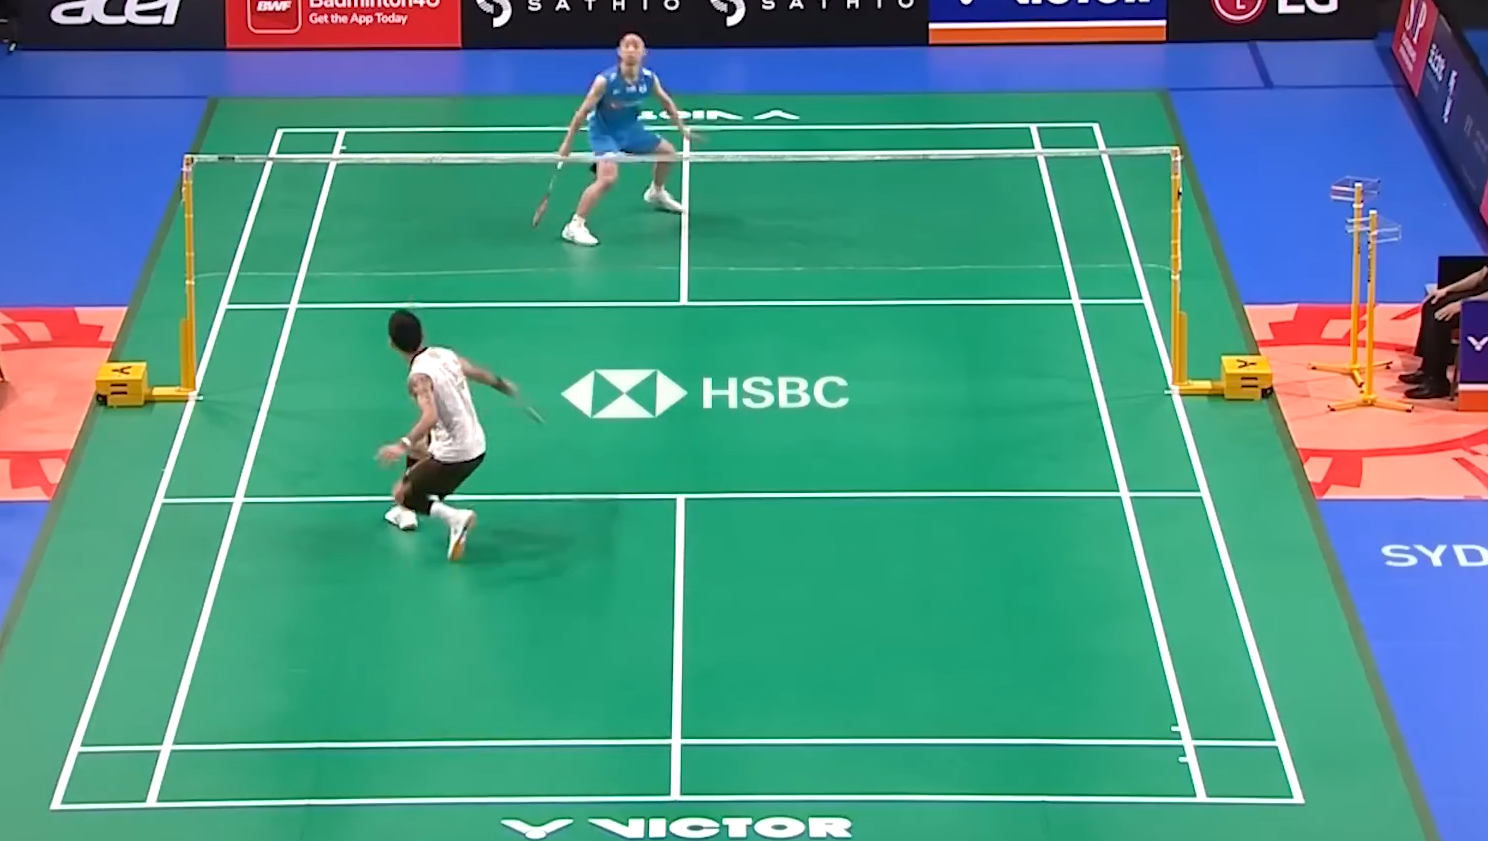

Success! Captured 4 points. You can now run the next cell.


In [77]:
import base64
import cv2
from google.colab import output
from IPython.display import HTML, display, Javascript

# 1. Load your local image and convert to base64 for JS
IMAGE_PATH = '/content/Screenshot 2026-03-18 200141.png'
img = cv2.imread(IMAGE_PATH)
h, w, _ = img.shape
_, buffer = cv2.imencode('.png', img)
img_base64 = base64.b64encode(buffer).decode('utf-8')

# 2. JavaScript to Python Bridge
user_points = []
def collect_points(points):
    global user_points
    user_points = points
    print(f"Success! Captured {len(user_points)} points. You can now run the next cell.")

output.register_callback('notebook.collect_points', collect_points)

# 3. Create the Interactive HTML/JS interface
html_content = f"""
<div id="container">
    <h3>Click the 4 outer corners of the court (TL, TR, BR, BL)</h3>
    <canvas id="canvas" width="{w}" height="{h}" style="border:1px solid #000; cursor: crosshair; max-width: 100%;"></canvas>
    <br><button id="done_btn" style="padding: 10px 20px; background: #4CAF50; color: white; border: none; border-radius: 5px; cursor: pointer;">Finished Clicking</button>
</div>

<script>
    var canvas = document.getElementById('canvas');
    var ctx = canvas.getContext('2d');
    var points = [];

    var img = new Image();
    img.onload = function() {{
        ctx.drawImage(img, 0, 0);
    }};
    img.src = "data:image/png;base64,{img_base64}";

    canvas.onclick = function(e) {{
        var rect = canvas.getBoundingClientRect();
        var x = (e.clientX - rect.left) * (canvas.width / rect.width);
        var y = (e.clientY - rect.top) * (canvas.height / rect.height);
        points.push([x, y]);

        ctx.fillStyle = "red";
        ctx.beginPath();
        ctx.arc(x, y, 8, 0, 2 * Math.PI);
        ctx.fill();
        ctx.strokeStyle = "white";
        ctx.stroke();
    }};

    document.getElementById('done_btn').onclick = function() {{
        google.colab.kernel.invokeFunction('notebook.collect_points', [points], {{}});
        document.getElementById('done_btn').innerText = "Points Saved!";
    }};
</script>
"""

display(HTML(html_content))

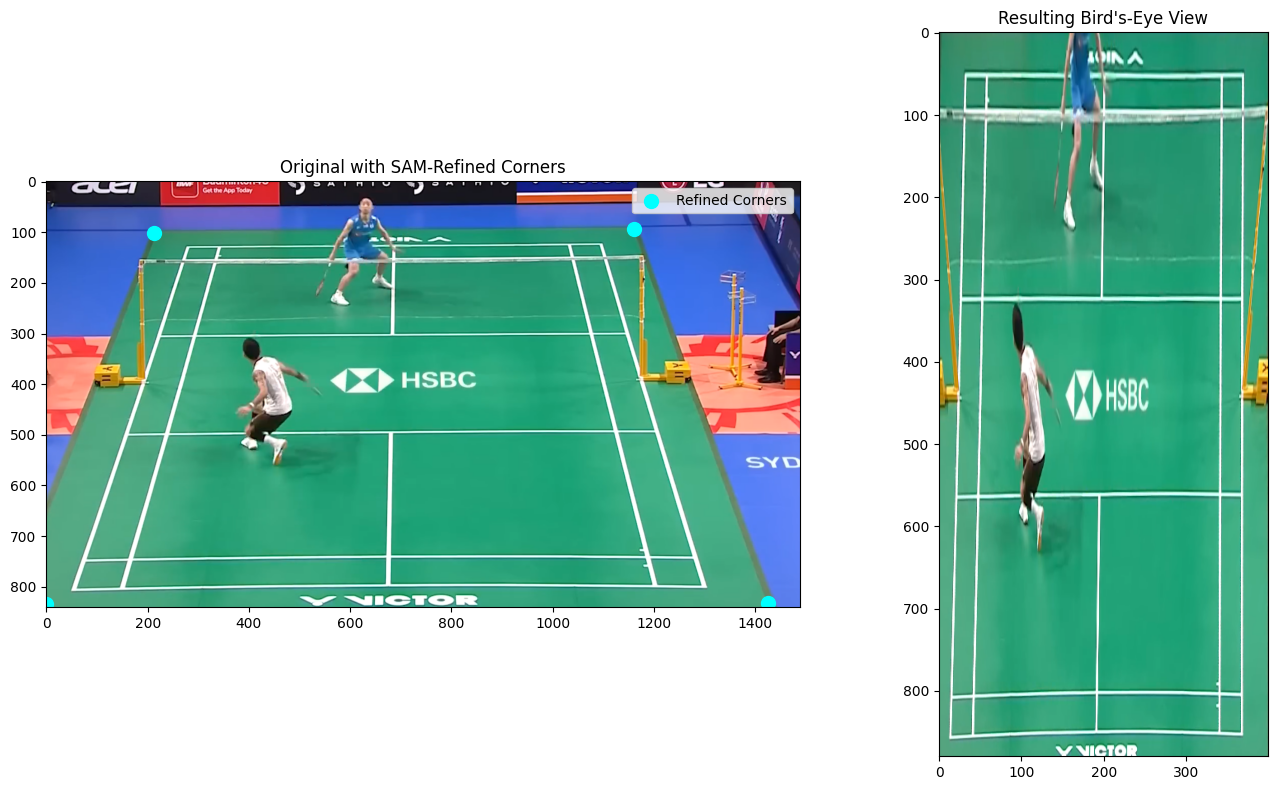


Homography Matrix (H) saved. You can use this for any frame in this video.


In [80]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import supervision as sv

# 1. Prepare the points for SAM
# user_points comes from the previous interactive cell
input_points = np.array(user_points)
input_labels = np.ones(len(input_points)) # 1 = Foreground/Object

# 2. Run SAM Predictor
# Ensure image_rgb is defined from your loading step
mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

# Pick the mask with the highest confidence score
best_mask = masks[np.argmax(scores)]

# 3. Refine the 4 Corners from the Mask
# We use the mask extrema to ensure the corners are pixel-perfect
coords = np.argwhere(best_mask > 0)[:, [1, 0]]
s = coords.sum(axis=1)
diff = np.diff(coords, axis=1)

src_pts = np.array([
    coords[np.argmin(s)],    # Top-Left
    coords[np.argmin(diff)], # Top-Right
    coords[np.argmax(s)],    # Bottom-Right
    coords[np.argmax(diff)]  # Bottom-Left
], dtype="float32")

# 4. Define Bird's-Eye View (Destination)
# Standard Badminton Court ratio (13.4m x 6.1m)
dst_w, dst_h = 400, 880
dst_pts = np.array([
    [0, 0],
    [dst_w - 1, 0],
    [dst_w - 1, dst_h - 1],
    [0, dst_h - 1]
], dtype="float32")

# 5. Calculate Transformation and Warp
H, _ = cv2.findHomography(src_pts, dst_pts)
birdseye_view = cv2.warpPerspective(image_rgb, H, (dst_w, dst_h))

# 6. Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

ax[0].imshow(image_rgb)
ax[0].scatter(src_pts[:, 0], src_pts[:, 1], color='cyan', s=100, label='Refined Corners')
ax[0].set_title("Original with SAM-Refined Corners")
ax[0].legend()

ax[1].imshow(birdseye_view)
ax[1].set_title("Resulting Bird's-Eye View")

plt.tight_layout()
plt.show()

# Save the matrix for future use (e.g., video processing)
print("\nHomography Matrix (H) saved. You can use this for any frame in this video.")

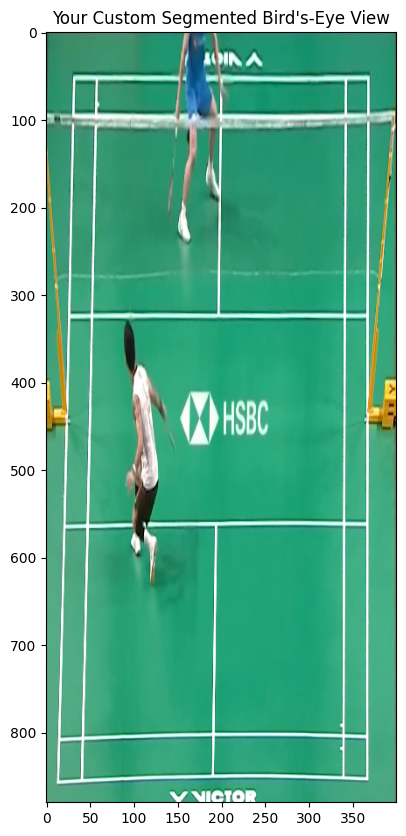

In [79]:
# Destination points (Bird's-Eye View Rectangle)
dst_w, dst_h = 400, 880
dst_pts = np.array([[0,0], [dst_w-1, 0], [dst_w-1, dst_h-1], [0, dst_h-1]], dtype="float32")

# Calculate Transformation
H, _ = cv2.findHomography(src_pts, dst_pts)
birdseye = cv2.warpPerspective(image_rgb, H, (dst_w, dst_h))

# Plot Result
plt.figure(figsize=(10,10))
plt.imshow(birdseye)
plt.title("Your Custom Segmented Bird's-Eye View")
plt.show()

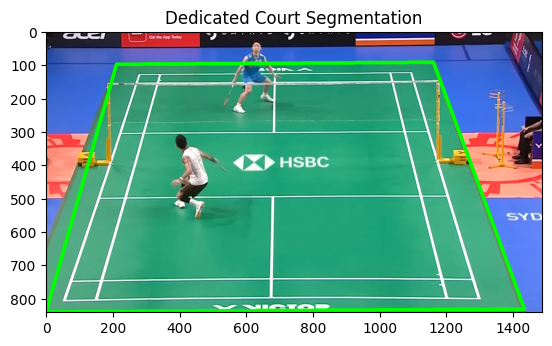

In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
IMAGE_PATH = '/content/Screenshot 2026-03-18 200141.png'
img = cv2.imread(IMAGE_PATH)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Define the exact range for Badminton Green
# We use a broad range to catch the court but avoid the blue floor
lower_green = np.array([40, 40, 40])
upper_green = np.array([90, 255, 255])

# 3. Create Mask and Clean it
mask = cv2.inRange(hsv, lower_green, upper_green)

# Remove small noise (people, net poles)
kernel = np.ones((15, 15), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 4. Find the Largest Quadrilateral (The Court)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
court_contour = max(contours, key=cv2.contourArea)

# Approximate the contour to a 4-sided polygon
peri = cv2.arcLength(court_contour, True)
approx = cv2.approxPolyDP(court_contour, 0.02 * peri, True)

# Ensure it's 4 points (if not, fallback to the bounding box)
if len(approx) == 4:
    src_pts = approx.reshape(4, 2).astype("float32")
else:
    # Fallback: find corners of the largest contour
    pts = court_contour.reshape(-1, 2)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    src_pts = np.array([pts[np.argmin(s)], pts[np.argmin(diff)],
                        pts[np.argmax(s)], pts[np.argmax(diff)]], dtype="float32")

# 5. Visualize
result = img.copy()
cv2.drawContours(result, [approx], -1, (0, 255, 0), 10)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Dedicated Court Segmentation")
plt.show()